In [6]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

[*********************100%***********************]  1 of 1 completed


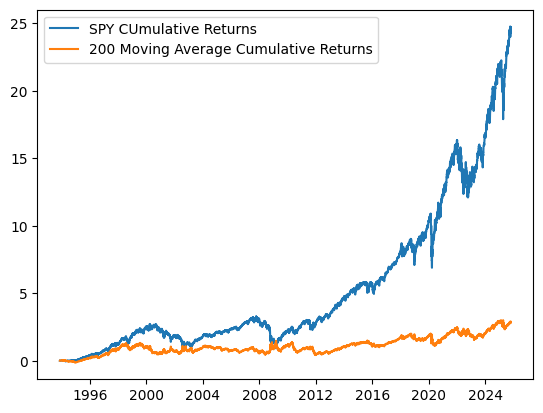

In [7]:
TICKER = 'SPY'
WINDOW = 200

def get_data():
    df = yf.download(TICKER)
    df.columns = df.columns.get_level_values(0)

    df['MA'] = df['Close'].rolling(WINDOW).mean()
    return df.dropna()

def add_strategy(df):
    df.columns = df.columns.get_level_values(0)
    df['Strategy'] = np.where(df['Close'] > df['MA'], 1, -1)
    df['Strategy'] = df['Strategy'].shift(1)
    return df

def test_strategy(df):
    df['asset_cumulative'] = np.cumprod(1 + df['Close'].pct_change()) - 1
    df['strategy_cumulative'] = np.cumprod(1 + df['Close'].pct_change() * df['Strategy']) - 1

    # plot the returns
    plt.plot(df['asset_cumulative'])
    plt.plot(df['strategy_cumulative'])
    plt.legend([f'{TICKER} CUmulative Returns', f'{WINDOW} Moving Average Cumulative Returns'])
    return df


def main():
    df = get_data()
    df = add_strategy(df)
    df = test_strategy(df)
    return df

df = main()

Text(0.5, 1.0, 'Close Price and Moving Average')

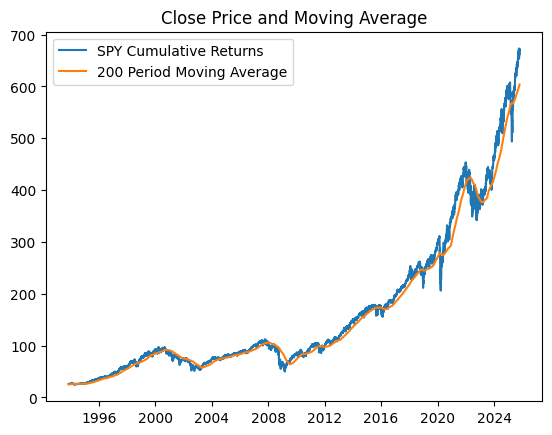

In [8]:
plt.plot(df['Close'])
plt.plot(df['MA'])
plt.legend([f'{TICKER} Cumulative Returns', f'{WINDOW} Period Moving Average'])
plt.title('Close Price and Moving Average')